# Mobile Companion Robot — State Space Model

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from scipy import signal

plt.style.use("seaborn-v0_8")

# Physical parameters
b = 0.5  # friction coefficient
m = 1.0  # robot mass

# State: [g, v_r] (gap, robot velocity)
# Input: [u, v_user] (robot force, user velocity)
A = np.array([[0, -1], [0, -b / m]])
B = np.array([[0, 1], [1 / m, 0]])
C = np.array([[1, 0]])  # observe only gap
D = np.array([[0, 0]])

In [13]:
SS = signal.StateSpace(A, B, C, D)

t = np.linspace(0, 100, 101)
u = np.zeros((len(t), 2))
u[10:20, 0] = 1.0   # robot force pulse
u[40:50, 0] = 2.0   # robot force pulse
u[60:80, 1] = 0.5   # user walks forward

t, y, x = signal.lsim(SS, u, t)

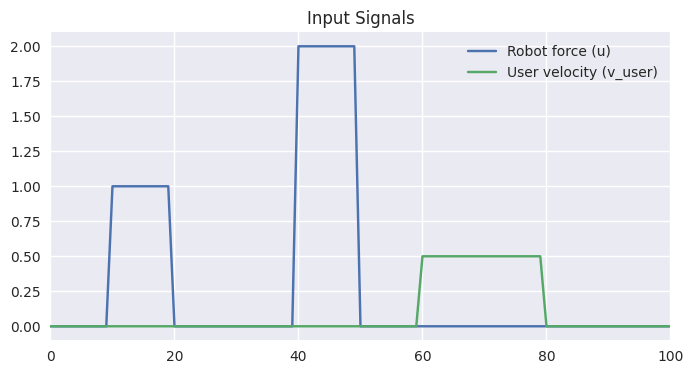

In [14]:
# Plot inputs
plt.figure(figsize=(8, 4))
plt.plot(t, u[:, 0], label="Robot force (u)")
plt.plot(t, u[:, 1], label="User velocity (v_user)")
plt.title("Input Signals")
plt.xlim(0, 100)
plt.legend()
plt.show()

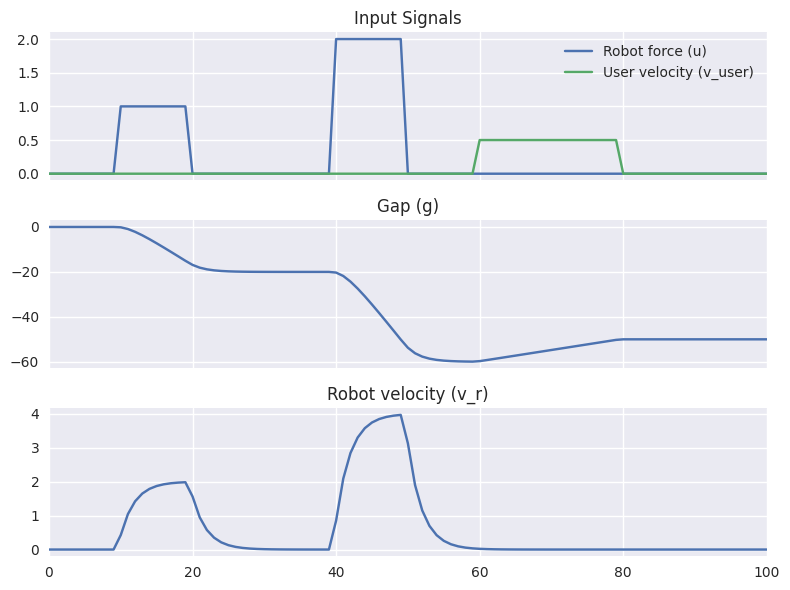

In [15]:
# Plot inputs and states
fig, ax = plt.subplots(3, 1, figsize=(8, 6), sharex=True)

ax[0].plot(t, u[:, 0], label="Robot force (u)")
ax[0].plot(t, u[:, 1], label="User velocity (v_user)")
ax[0].set_title("Input Signals")
ax[0].set_xlim(0, 100)
ax[0].legend()

ax[1].plot(t, x[:, 0])
ax[1].set_title("Gap (g)")
ax[1].set_xlim(0, 100)

ax[2].plot(t, x[:, 1])
ax[2].set_title("Robot velocity (v_r)")
ax[2].set_xlim(0, 100)

plt.tight_layout()
plt.show()